***
# Homework 7: pandas

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten, Amy Merkelz

**Date:** March 21st, 2024
***

In [1]:
import scipy as sp
import scipy.optimize as opt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1.) Warmup: constructing pandas objects (2 points, spent $\approx$ 10 minutes)

**In this problem, you will create two simple pandas objects.**

**Create a `pandas` Series object with indices given by the first 10 letters of the English alphabet in lower-case and values given by the first 10 primes. Store it in a variable called `alphabet`.**

In [2]:
# copied the prime_gen() generator from ssudhir2_hw5.ipynb
def primes_gen():
    '''
    A generator function that enumerates the prime numbers.

    Example usage:
    >>> primes_gen = primes_gen()
    >>> for i in range(5):
    >>>     print(next(primes_gen))
    '''
    curr = 2 # first prime number
    yield curr

    while True:
        curr += 1 # check the next number after curr = 2.
        # 1. Check if curr is divisible by any number between 2 and sqrt(curr).
        # 2. If curr is not divisible by any number between 2 and sqrt(curr), then yield square of curr.
        # 3. Else, check if the next number is prime.
        while any( (curr % i) == 0 for i in range(2, int(curr**0.5) + 1) ) == True:
            curr += 1 # if curr is not prime, check the next number
            
        yield curr # if curr is prime, yield it

primes = primes_gen() # create a generator object
primes_10 = [next(primes) for i in range(10)] # get the first 10 prime numbers

indices = [chr(i) for i in range(65, 75)] # get the first 10 alphabets by their ASCII values

alphabet = pd.Series(data = primes_10, # data is the first 10 prime numbers 
                     index = indices) # index is the first 10 alphabets

print(alphabet)

A     2
B     3
C     5
D     7
E    11
F    13
G    17
H    19
I    23
J    29
dtype: int64


**Below is a table that might arise in a genetics experiment. Reconstruct this as a pandas DataFrame. Store it in a variable called `simple_table`.** 

**Note: be sure that your table has a hierarchical row index, just like this table does.**

In [3]:
simple_table = pd.DataFrame({

    'animal' : ['goat', 'goat', 'goat', 'goat', 
                'bird', 'bird', 'bird', 'bird',
                'llama', 'llama', 'llama', 'llama'], # first column, repeating each observation 4 times

    'parent1' : ['A', 'A',
                 'a', 'a',
                 'A', 'A',
                 'a', 'a',
                 'A', 'A',
                 'a', 'a'], # second column, repeating each observation 2 times

    'parent2' : ['A', 'a',
                 'A', 'a',
                 'A', 'a',
                 'A', 'a',
                 'A', 'a',
                 'A', 'a'], # third column, alternating between the 2 observations

    'score1' : [1,2,3,4,5,6,7,8,9,10,11,12], # fourth column, numerical values as given
    
    'score2' : [2,4,4,6,6,8,8,10,10,12,12,14]}) # fifth column, numerical values as given

simple_table.set_index(['animal', 'parent1', 'parent2'], inplace = True) # set the index to be hierarchical for the first 3 columns
print(simple_table)

                        score1  score2
animal parent1 parent2                
goat   A       A             1       2
               a             2       4
       a       A             3       4
               a             4       6
bird   A       A             5       6
               a             6       8
       a       A             7       8
               a             8      10
llama  A       A             9      10
               a            10      12
       a       A            11      12
               a            12      14


## 2.) Working with pandas DataFrames (3 points, spent $\approx$ 15 minutes)

**In this problem, you’ll get practice working with pandas DataFrames, reading them into and out of memory, changing their contents and performing aggregation operations.** 

**For this problem, you’ll need to download the celebrated iris data set, available as a .csv file from my website: http://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/iris.csv** 

**Note: for the sake of consistency, please use this version of the CSV, and not one from elsewhere (e.g., downloaded from the UC Irvine repository).**

**Download the iris data set from the link above. Please include this file in your submission.** 

**Read iris.csv into Python as a pandas DataFrame. Note that the CSV file includes column headers.** 

* **How many data points are there in this data set?** 

* **What are the data types of the columns?**

* **What are the column names? The column names correspond to flower species names, as well as four basic measurements one can make of a flower: the width and length of its petals and the width and length of its sepal (the part of the plant that supports and protects the flower itself).** 

* **How many species of flower are included in the data?**

In [4]:
iris = pd.read_csv('iris.csv') # read the iris dataset using pandas

# relevant print statements to answer the above questions
print(f'There are {len(iris)} data points in the iris dataset.')
print('\n')
print(f'The datatypes of the columns in the iris dataset are:')
print(iris.dtypes)
print('\n')
print(f'The column names in the iris dataset are:')
print(iris.columns)
print('\n')
print(f'The species of flowers in the iris dataset are:')
print(pd.unique(iris['Species']))
print('\n')
print(f'The number of species of flowers in the iris dataset are:')
print(len(pd.unique(iris['Species'])))

There are 150 data points in the iris dataset.


The datatypes of the columns in the iris dataset are:
Sepal.Length    float64
Sepal.Width     float64
Petal.Length    float64
Petal.Width     float64
Species          object
dtype: object


The column names in the iris dataset are:
Index(['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width',
       'Species'],
      dtype='object')


The species of flowers in the iris dataset are:
['setosa' 'versicolor' 'virginica']


The number of species of flowers in the iris dataset are:
3


**The data that I uploaded to my website, which you have downloaded, is based on the data initially uploaded to the UC Irvine machine learning repository. It is now known that this data contains errors in two of its rows (see the documentation at https://archive.ics.uci.edu/ml/datasets/Iris). Using 1-indexing, these errors are in the 35th and 38th rows. The 35th row should read `4.9, 3.1, 1.5, 0.2, "setosa"`, where the fourth feature is incorrect as it appears in the file, and the 38th row should read `4.9, 3.6, 1.4, 0.1, "setosa"`, where the second and third features are incorrect as they appear in the file. Correct these entries of your DataFrame.**

In [5]:
iris.at[34, 'Petal.Width'] = 0.2 # change the value of Petal.Width in the 35th row to 0.2

iris.at[37, 'Sepal.Width'] = 3.6 # change the value of Sepal.Width in the 38th row to 3.6
iris.at[37, 'Petal.Length'] = 1.4 # change the value of Petal.Length in the 38th row to 1.4

# relevant print statements confirm the changes
print(iris.iloc[34])
print('\n')
print(iris.iloc[37])

Sepal.Length       4.9
Sepal.Width        3.1
Petal.Length       1.5
Petal.Width        0.2
Species         setosa
Name: 34, dtype: object


Sepal.Length       4.9
Sepal.Width        3.6
Petal.Length       1.4
Petal.Width        0.1
Species         setosa
Name: 37, dtype: object


**The iris dataset is commonly used in machine learning as a proving ground for clustering and classification algorithms. Some researchers have found it useful to use two additional features, called *Petal ratio* and *Sepal ratio*, defined as the ratio of the petal length to petal width and the ratio of the sepal length to sepal width, respectively.**

**Add two columns to your DataFrame corresponding to these two new features. Name these columns `Petal.Ratio` and `Sepal.Ratio`, respectively.**

In [6]:
# adding new ratio columns to the iris dataset for both Petal and Sepal
iris['Petal.Ratio'] = round(iris['Petal.Length'] / iris['Petal.Width'], 1)
iris['Sepal.Ratio'] = round(iris['Sepal.Length'] / iris['Sepal.Width'], 1)

# reordering the columns in the iris dataset for brevity
iris = iris.reindex(columns = ['Sepal.Length', 'Sepal.Width', 'Sepal.Ratio', 'Petal.Length', 'Petal.Width', 'Petal.Ratio', 'Species'])
iris

,Sepal.Length,Sepal.Width,Sepal.Ratio,Petal.Length,Petal.Width,Petal.Ratio,Species
0,5.1,3.5,1.5,1.4,0.2,7.0,setosa
1,4.9,3.0,1.6,1.4,0.2,7.0,setosa
2,4.7,3.2,1.5,1.3,0.2,6.5,setosa
3,4.6,3.1,1.5,1.5,0.2,7.5,setosa
4,5.0,3.6,1.4,1.4,0.2,7.0,setosa
...,...,...,...,...,...,...,...
145,6.7,3.0,2.2,5.2,2.3,2.3,virginica
146,6.3,2.5,2.5,5.0,1.9,2.6,virginica
147,6.5,3.0,2.2,5.2,2.0,2.6,virginica
148,6.2,3.4,1.8,5.4,2.3,2.3,virginica


**Save your corrected and extended iris DataFrame to a csv file called `iris_corrected.csv`. Please include this file in your submission**

In [7]:
iris.to_csv('iris_corrected.csv', index = False) # save the corrected iris dataset to a csv file

**Use a `pandas` aggregate operation to determine the mean, median, minimum, maximum and standard deviation of the petal and sepal ratio for each of the three species in the data set.** 

**Store the results of your aggregation operation in a variable called `species_agg`. The rows of your table should be indexed by the function names `mean`, `median`, `min`, `max` and `std`, and the columns should be the same as the species names from the iris data frame.** 

**Note: you should be able to get all of these numbers in a single table using a single line of code**

In [8]:
# group the iris dataset by Species and calculate the mean, median, min, max, and standard deviation of the Sepal.Ratio and Petal.Ratio columns
species_agg = iris.groupby('Species')[['Sepal.Ratio', 'Petal.Ratio']].aggregate(['mean', 'median', 'min', 'max', 'std']).T
species_agg

Species                setosa  versicolor  virginica
Sepal.Ratio mean     1.474000    2.154000   2.230000
            median   1.500000    2.200000   2.200000
            min      1.300000    1.800000   1.800000
            max      2.000000    2.800000   3.000000
            std      0.125860    0.224254   0.250102
Petal.Ratio mean     6.910000    3.244000   2.776000
            median   7.000000    3.200000   2.700000
            min      2.700000    2.700000   2.100000
            max     15.000000    4.100000   4.000000
            std      2.852586    0.313089   0.408861

**Create a scatterplot of the iris specimens, with sepal ratio on the x-axis and petal ratio on the y-axis, and with observations colored according to species. Save your plot in a file called `iris_scatter.pdf`. Please include this file in your submission.**

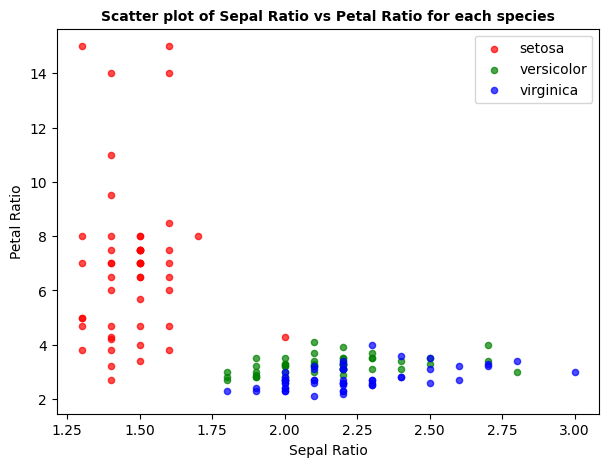

In [9]:
fig, ax = plt.subplots(1, 1, figsize = (7, 5)) # create a figure and axis object

for (species, data) in iris.groupby('Species'): # iterate over the species and their corresponding data

    if species == 'setosa':
        ax = data.plot.scatter(x = 'Sepal.Ratio', # Sepal Ratio on the x-axis
                               y = 'Petal.Ratio', # Petal Ratio on the y-axis
                               label = species, # set the label to the species
                               alpha = 0.7, # set the transparency of the points to 0.7
                               color = 'red', # set the color of the points to red for setosa
                               ax = ax) # set the axis to the current axis
    
    elif species == 'versicolor':
        ax = data.plot.scatter(x = 'Sepal.Ratio', # Sepal Ratio on the x-axis
                               y = 'Petal.Ratio', # Petal Ratio on the y-axis
                               label = species, # set the label to the species
                               alpha = 0.7, # set the transparency of the points to 0.7
                               color = 'green', # set the color of the points to green for versicolor
                               ax = ax) # set the axis to the current axis
    
    else:
        ax = data.plot.scatter(x = 'Sepal.Ratio', # Sepal Ratio on the x-axis
                               y = 'Petal.Ratio', # Petal Ratio on the y-axis
                               label = species, # set the label to the species
                               alpha = 0.7, # set the transparency of the points to 0.7
                               color = 'blue', # set the color of the points to blue for virginica
                               ax = ax) # set the axis to the current axis
    
    # set the title, x-axis label, and y-axis label
    ax.set_title('Scatter plot of Sepal Ratio vs Petal Ratio for each species',
                 fontsize = 10,
                 fontweight = 'bold')
    ax.set_xlabel('Sepal Ratio')
    ax.set_ylabel('Petal Ratio')

# save the figure to a pdf file
fig.savefig('iris_scatter.pdf')

## 3.) Plotting Dataframes: Major League Baseball (5 points, spent $\approx$ 30 minutes)

**In this problem, you’ll get more practice working with `pandas` data frames and performing basic plotting. We’ll work with a data set consisting of all the baseball games from the 2023 Major League Baseball (MLB) regular season, compiled by retrosheet.org. Don’t worry– you don’t need to know anything about baseball to complete this assignment!** 

**You can download the relevant CSV file (in a zipped archive) either from the course web page at http://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/mlb2023.zip or directly from the original source at https://www.retrosheet.org/gamelogs/gl2023.zip.** 

**Note: even though the zipped file is named as a `.txt` file, it is in fact a CSV file, which pandas will still be able to read.**

**Requisite legal boilerplate: The information used here was obtained free of charge from and is copyrighted by Retrosheet. Interested parties may contact Retrosheet at “www.retrosheet.org”.**

**Read the data into a table called `mlb_df`. Each row of the table represents the outcome of a single game from the 2023 MLB season. Take note that the file does not have columns names; see the header keyword to the `pandas.read_csv` function. The columns are explained in a `.txt` file which you can download from https://www.retrosheet.org/gamelogs/glfields.txt, but we will only make use of a few of them in this problem.** 

**The 10-th and 11-th columns (using 1-indexing) are the scores of the visiting and home teams, respectively. Rename these columns `v_score` and `h_score`, respectively. MLB comprises two leagues, the American League and the National League, encoded as `AL` and `NL` in the table. The 5-th and 8-th columns (also 1-indexed) are the league affiliations of the visiting and home team, respectively. Rename these columns `v_league` and `h_league`.**

In [10]:
mlb_df = pd.read_csv('gl2023.txt', header = None)
mlb_df = mlb_df.rename(columns = {4: 'v_league', 7: 'h_league', 9: 'v_score', 10: 'h_score'})
mlb_df.iloc[:, : 12]

,0,1,2,3,v_league,5,6,h_league,8,v_score,h_score,11
0,20230330,0,Thu,MIL,NL,1,CHN,NL,1,0,4,51
1,20230330,0,Thu,PIT,NL,1,CIN,NL,1,5,4,54
2,20230330,0,Thu,ARI,NL,1,LAN,NL,1,2,8,51
3,20230330,0,Thu,NYN,NL,1,MIA,NL,1,5,3,54
4,20230330,0,Thu,COL,NL,1,SDN,NL,1,7,2,54
...,...,...,...,...,...,...,...,...,...,...,...,...
2425,20231001,0,Sun,SDN,NL,162,CHA,AL,162,2,1,66
2426,20231001,0,Sun,CLE,AL,162,DET,AL,162,2,5,51
2427,20231001,0,Sun,NYA,AL,162,KCA,AL,162,2,5,51
2428,20231001,0,Sun,TEX,AL,162,SEA,AL,162,0,1,51


**Create a plot with two subplots, placed side-by-side. Each subplot should be a scatter plot in which the x- and y-axes correspond to the home and visitor scores, respectively, and in which each point corresponds to a game from the season.**

* **In the left-hand plot, include all games in which both teams were in the NL, and in the right hand plot, include all games in which both teams were in the AL.** 

* **Games in which the teams were from different leagues should be ignored. Specify the transparency (cf. the `alpha` parameter in the `matplotlib` documentation) so that scores that occur more often will be shaded darker than rare scores.**

* **Color the points in the scatter plot according to the league affiliation of the two teams as follows: games between two teams both in the AL should be rendered as red points in the scatter plot. Games between two teams both in the NL should be rendered as blue points in the scatter plot.**

* **Label your axes and provide an appropriate title for your plot as well as its subplots. Save your plot in a file called `home_away.pdf` and include it in your submission.** 

**Note: you may find it useful to create an extra column in the data frame encoding whether a given game is AL vs AL, NL vs NL or mixed.**

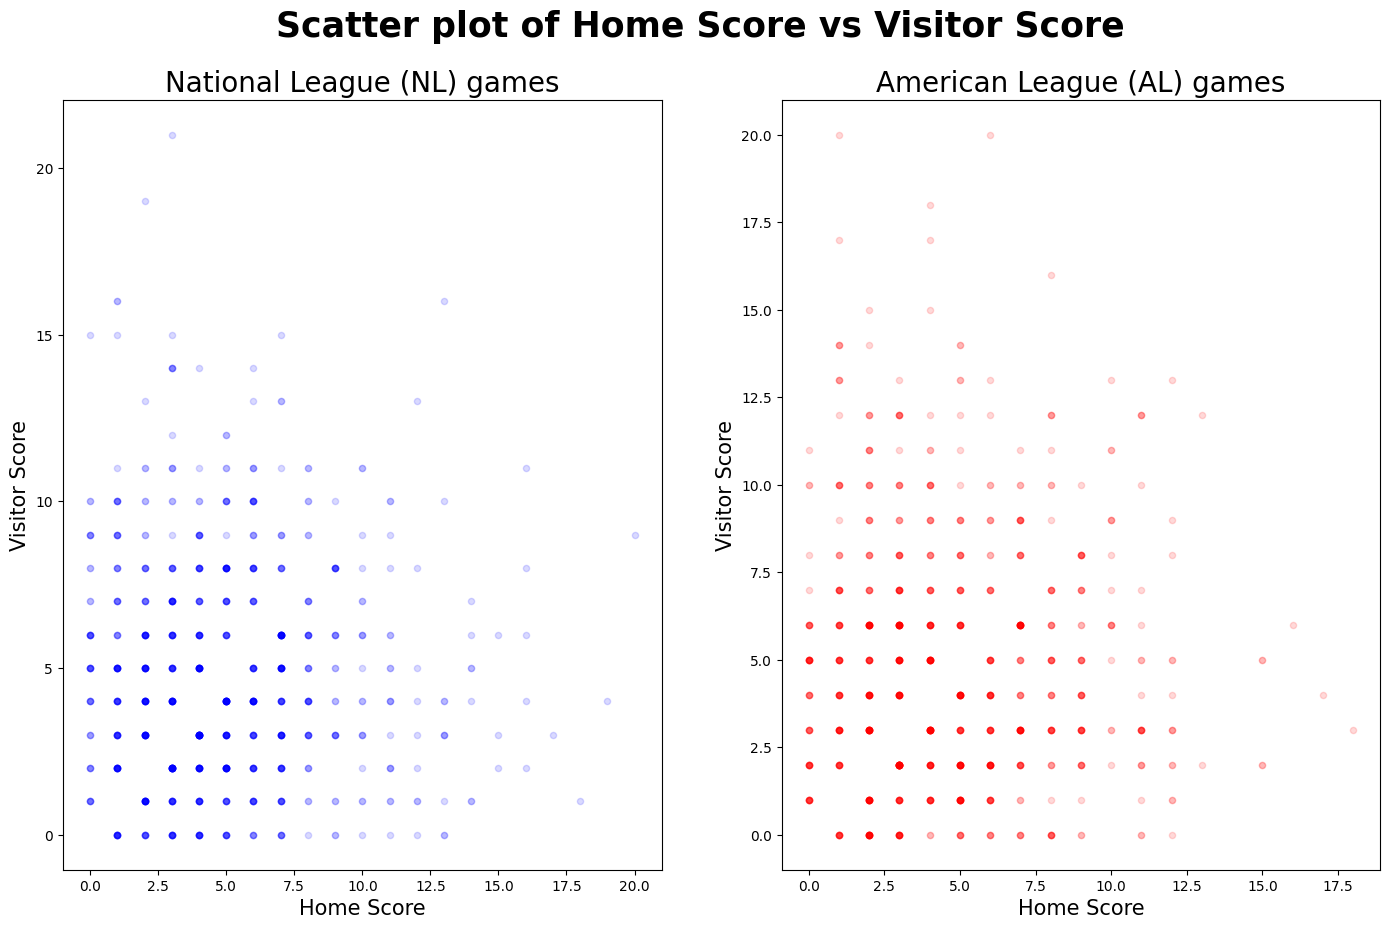

In [11]:
NL = mlb_df[ (mlb_df['v_league'] == 'NL') & (mlb_df['h_league'] == 'NL') ] # subset the dataframe for v_league == h_league == NL games
AL = mlb_df[ (mlb_df['v_league'] == 'AL') & (mlb_df['h_league'] == 'AL') ] # subset the dataframe for v_leagure == h_league == AL games

fig, axs = plt.subplots(1, 2, figsize = (17, 10))

NL.plot.scatter(x = 'h_score', # NL Home Score on the x-axis
                y = 'v_score', # NL Visitor Score on the y-axis
                c = 'blue', # set the color of the points to blue
                alpha = 0.15, # set the transparency of the points to 0.15, points that are grouped together will be darker
                ax = axs[0]) # set the axis to the left axis

AL.plot.scatter(x = 'h_score', # AL Home Score on the x-axis
                y = 'v_score', # AL Visitor Score on the y-axis
                c = 'red', # set the color of the points to red
                alpha = 0.15, # set the transparency of the points to 0.15, points that are grouped together will be darker
                ax = axs[1]) # set the axis to the right axis

# set the title, x-axis label, and y-axis label for the scatter plots and subplots
fig.suptitle('Scatter plot of Home Score vs Visitor Score',
             y = 0.97,
             fontsize = 25,
             fontweight = 'bold')

axs[0].set_title('National League (NL) games', fontsize = 20)
axs[0].set_xlabel('Home Score', fontsize = 15)
axs[0].set_ylabel('Visitor Score', fontsize = 15)

axs[1].set_title('American League (AL) games', fontsize = 20)
axs[1].set_xlabel('Home Score', fontsize = 15)
axs[1].set_ylabel('Visitor Score', fontsize = 15)

# save the figure to a pdf file
fig.savefig('home_away.pdf')

**The Skellam distribution (https://en.wikipedia.org/wiki/Skellam_distribution) is the distribution that results from taking the difference between two Poisson random variables. It is often suggested as a model for the difference between scores in sports games, particularly baseball.**

* **Add a new column to the data frame called `score_diff`, given by the home score minus the away score.** 

* **Make a histogram of this score difference and give the plot an appropriate title. Save your histogram in a file `score_diff.pdf` and include it in your submission.**

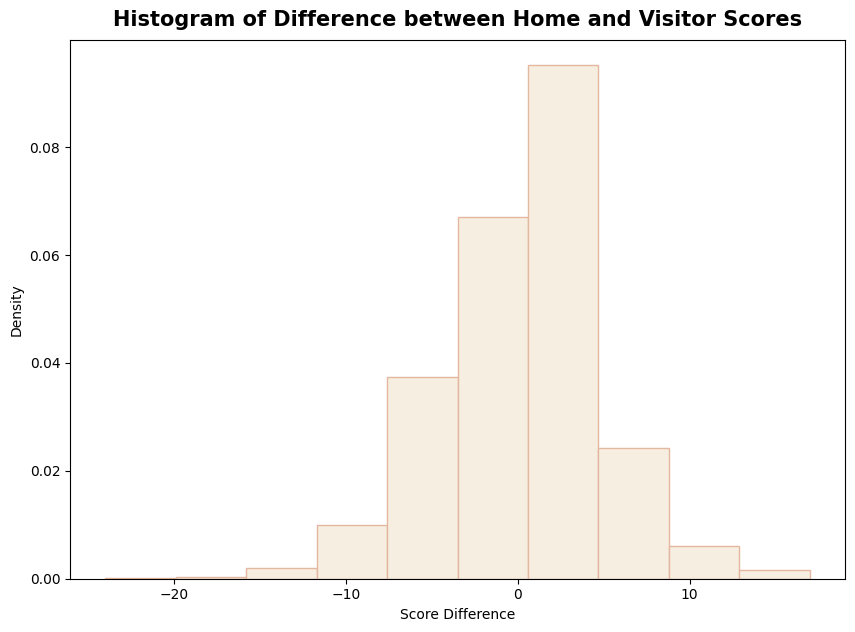

In [12]:
mlb_df['score_diff'] = mlb_df['h_score'] - mlb_df['v_score'] # calculate the difference between Home and Visitor scores

fig, ax = plt.subplots(1, 1, figsize = (10, 7)) # create a figure and axis object

mlb_df['score_diff'].plot.hist(bins = 10, # create a histogram with 10 bins
                               density = True, # normalize the histogram
                               alpha = 1, # set the transparency of the bars to 1
                               edgecolor = '#E4B7A0', # set the edge color of the bars to a light shade of red
                               color = '#F6EEE0', # set the color of the bars to a light shade of yellow
                               ax = ax)

# set the title, x-axis label, and y-axis label for the histogram
ax.set_title('Histogram of Difference between Home and Visitor Scores',
             y = 1.01,
             fontsize = 15,
             fontweight = 'bold')
ax.set_xlabel('Score Difference')
ax.set_ylabel('Density')

# save the figure to a pdf file
fig.savefig('score_diff.pdf')

**Read the documentation about the scipy implementation of the Skellam distribution at https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skellam.html. If $\lambda_H$ and $\lambda_V$ are the means of two independent Poisson random variables $K_H$ and $K_V$, respectively, then the Skellam distribution that describes the difference $K_H − K_V$ has parameters $\lambda_H$ and $\lambda_V$. We will assume (perhaps incorrectly) that the location parameter of the Skellam distribution (loc in the scipy documentation) is $0$. To fit a Skellam distribution to the data, we will first fit Poisson distributions to the home and away teams.**

**Estimate parameters $\hat\lambda_H$ and $\hat\lambda_V$ as the means of the home and visitor scores, respectively. There are several possible ways to assess how well a Skellam distribution with parameters $(\mu_1, \mu_2) = (\hat\lambda_H, \hat\lambda_V)$ and location parameter $0$ describe the data. The most obvious would be to use a chi-square test or the Cressie-Read test (though admittedly, I am suggesting these primarily because they are already implemented in scipy).** 

**One problem with both of these is that they require either a finite number of categories or that, heuristically, the expected count be at least five for all categories. Both of these requirements are failed by the Skellam distribution, since it has infinite support, and it puts miniscule probabilities on large values.** 

**There are several possible ways to fix this problem. Indeed, if you look at the data, you will likely observe several other problems, most notably that baseball games cannot end in ties (aside from a few exceptional circumstances), and therefore our data will include few if any zeros, in contradiction with the prediction of the Skellam distribution.** 

**Taking these various concerns (and any others you may find) into account, perform an analysis to assess whether or not the Skellam distribution (perhaps after some modification, such as removing the zero outcome) adequately explains the data.** 

**Note: this problem is purposefully open-ended, and there is no right answer, per se. The point of this problem is to get you doing some exploratory data analysis on your own. Explain your decisions clearly and you will receive full credit (so long as said decisions are reasonable!)**

The Skellam Distribution is defined as follows, for parameters $\mu_1 \ge 0$, $\mu_2 \ge 0$ over the support $k \in \{\dots, -2, -1, 0, 1, 2, \dots\}$, the pmf is:

$$ f(k; \mu_1, \mu_2) = \text{exp}(-(\mu_1 + \mu_2)) \cdot \bigg(\frac{\mu_1}{\mu_2}\bigg)^{k/2} I_{|k|}(2\sqrt{\mu_1\mu_2}) $$

where $I_{|k|}(z)$ is the modified Bessel Function

We can use the Maximum Likelihood Estimator (MLE) to estimate $\hat\mu_1$ and $\hat\mu_2$. `scipy.optimize` contains optimization algorithms like BFGS, Nelder_Mead, CG, and others. I chose to use Nelder-Mead method of optimization as it a non-gradient in nature thus does not require computing the derivative. The pmf of the distribution was obtained using `scipy.stats.skellam.pmf` and its negative log-likelihood was computed using `np.sum` and `np.log`.

In [13]:
def skellam_dist(k, mu1, mu2):
    '''
    Returns the Skellam distribution for the given parameters.

    Inputs:
    k (int): The difference between the two Poisson random variables.
    mu1 (float): The mean of the first Poisson random variable.
    mu2 (float): The mean of the second Poisson random variable.

    Outputs:
    float: The probability of the difference between the two Poisson random variables being k.
    '''
    return sp.stats.skellam.pmf(k, mu1, mu2) # return the probability mass function of the Skellam distribution

def neg_log_lik(par, data):
    '''
    Returns the negative log likelihood of the Skellam distribution.

    Inputs:
    par (list): A list of parameters to be optimized, in this case, the means of the two Poisson random variables.
    data (array): The data points, in this case, the difference between the home and visitor scores.

    Outputs:
    float: The negative log likelihood of the Skellam distribution.
    '''
    mu1, mu2 = par # initialize the means of the two Poisson random variables
    return -np.sum(np.log(skellam_dist(data, mu1, mu2))) # return the negative log likelihood of the Skellam distribution

par = [0.5, 0.5] # Initial guess for the parameters
data = mlb_df['score_diff'] # Data points, i.e., the difference between the home and visitor scores

result = opt.minimize(neg_log_lik, par, args = data, method = 'Nelder-Mead') # Minimize the negative log likelihood
print(result)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 7109.371660635181
             x: [ 1.010e+01  1.014e+01]
           nit: 54
          nfev: 98
 final_simplex: (array([[ 1.010e+01,  1.014e+01],
                       [ 1.010e+01,  1.014e+01],
                       [ 1.010e+01,  1.014e+01]]), array([ 7.109e+03,  7.109e+03,  7.109e+03]))


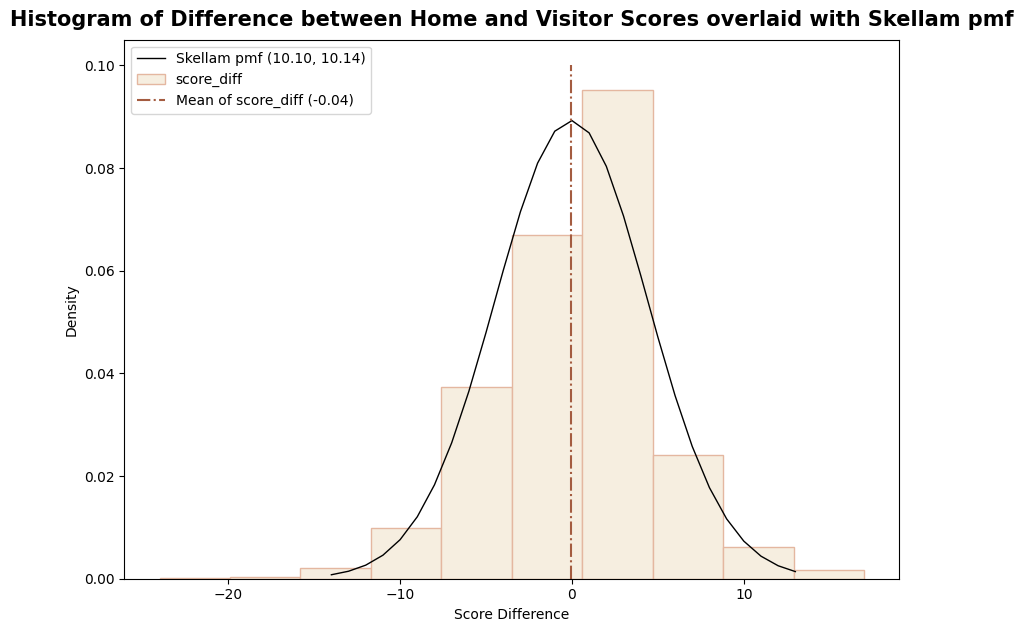

In [14]:
# Following documentation used to plot the pmf of Skellam distribution
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skellam.html

mu1 = result.x[0] # mean of the first Poisson random variable found by minimizing the negative log likelihood
mu2 = result.x[1] # mean of the second Poisson random variable found by minimizing the negative log likelihood
rv = sp.stats.skellam(mu1, mu2) # create a Skellam distribution object

# create an array of Skellam distriubted values
x = np.arange(sp.stats.skellam.ppf(0.001, mu1, mu2), # start from the 0.001 percentile
              sp.stats.skellam.ppf(0.999, mu1, mu2)) # end at the 0.999 percentile

fig, ax = plt.subplots(1, 1, figsize = (10, 7)) # create a figure and axis object

ax.plot(x, # x-axis values generated from the Skellam distribution
        rv.pmf(x), # y-axis values generated from the Skellam distribution
        color = 'black', # set the line color to black
        linewidth = 1, # set the line width to 1
        alpha = 1, # set the transparency of the line to 1
        label = f'Skellam pmf ({mu1:.2f}, {mu2:.2f})') # set the label to the Skellam distribution

# same code as above to plot the histogram
mlb_df['score_diff'].plot.hist(bins = 10, 
                               density = True,
                               alpha = 1,
                               edgecolor = '#E4B7A0', 
                               color = '#F6EEE0',
                               ax = ax)

ax.vlines(np.mean(mlb_df['score_diff']), # x-axis value for the mean of the difference between the home and visitor scores
          ymin = 0, # start from y = 0
          ymax = 0.1, # end at y = 0.1
          alpha = 1, # set the transparency of the line to 1
          color = '#A45C40', # set the color of the line to a light shade of brown
          linestyle = 'dashdot', # set the line style to dashdot
          label = f'Mean of score_diff ({np.mean(mlb_df["score_diff"]):.2f})') # set the label to the mean of the difference between the home and visitor scores

# set the title, x-axis label, and y-axis label for the histogram and pmf
ax.set_title('Histogram of Difference between Home and Visitor Scores overlaid with Skellam pmf', 
             y = 1.01,
             fontsize = 15,
             fontweight = 'bold')
ax.set_xlabel('Score Difference')
ax.set_ylabel('Density')
ax.legend(loc = 'upper left')

plt.show()

We can see that our Skellam distribution (black curve) overlays fairly well over the histogram and the mean of the score differences. By minimizing the negative log likelihood, we found the following estimates of our parameter:

$$ \mu_1 = 10.10, \quad \mu_2 = 10.14 $$

where $\mu_1 - \mu_2 = -0.04$ is the expected value of our distribution.